In [2]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("indiv_spearman_duplicates_grouped_norepeat_HT11_cnn2_ssDNA_target_ah.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("indiv_features_with_positive_IQR_HT11_cnn2_ssDNA_target_ah.csv", index=False)


                 Feature     Q1     Q3  Median Spearman Correlation
0          Pos1_Unpaired  0.577  0.577                        0.577
1          Pos2_Unpaired  0.498  0.605                        0.575
2          Pos4_Unpaired  0.746  0.776                        0.766
3    Pos6_Paired-Opening  0.045  0.381                        0.190
4          Pos7_Unpaired  0.089  0.245                        0.135
5    Pos8_Paired-Closing  0.075  0.226                        0.203
6    Pos9_Paired-Closing  0.296  0.370                        0.349
7   Pos10_Paired-Closing  0.105  0.336                        0.264
8         Pos11_Unpaired  0.190  0.301                        0.264
9         Pos12_Unpaired  0.404  0.645                        0.585
10        Pos13_Unpaired  0.103  0.605                        0.441
11        Pos14_Unpaired  0.219  0.459                        0.294
12        Pos15_Unpaired  0.472  0.722                        0.680
13        Pos16_Unpaired  0.330  0.716          

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_46948/557033581.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


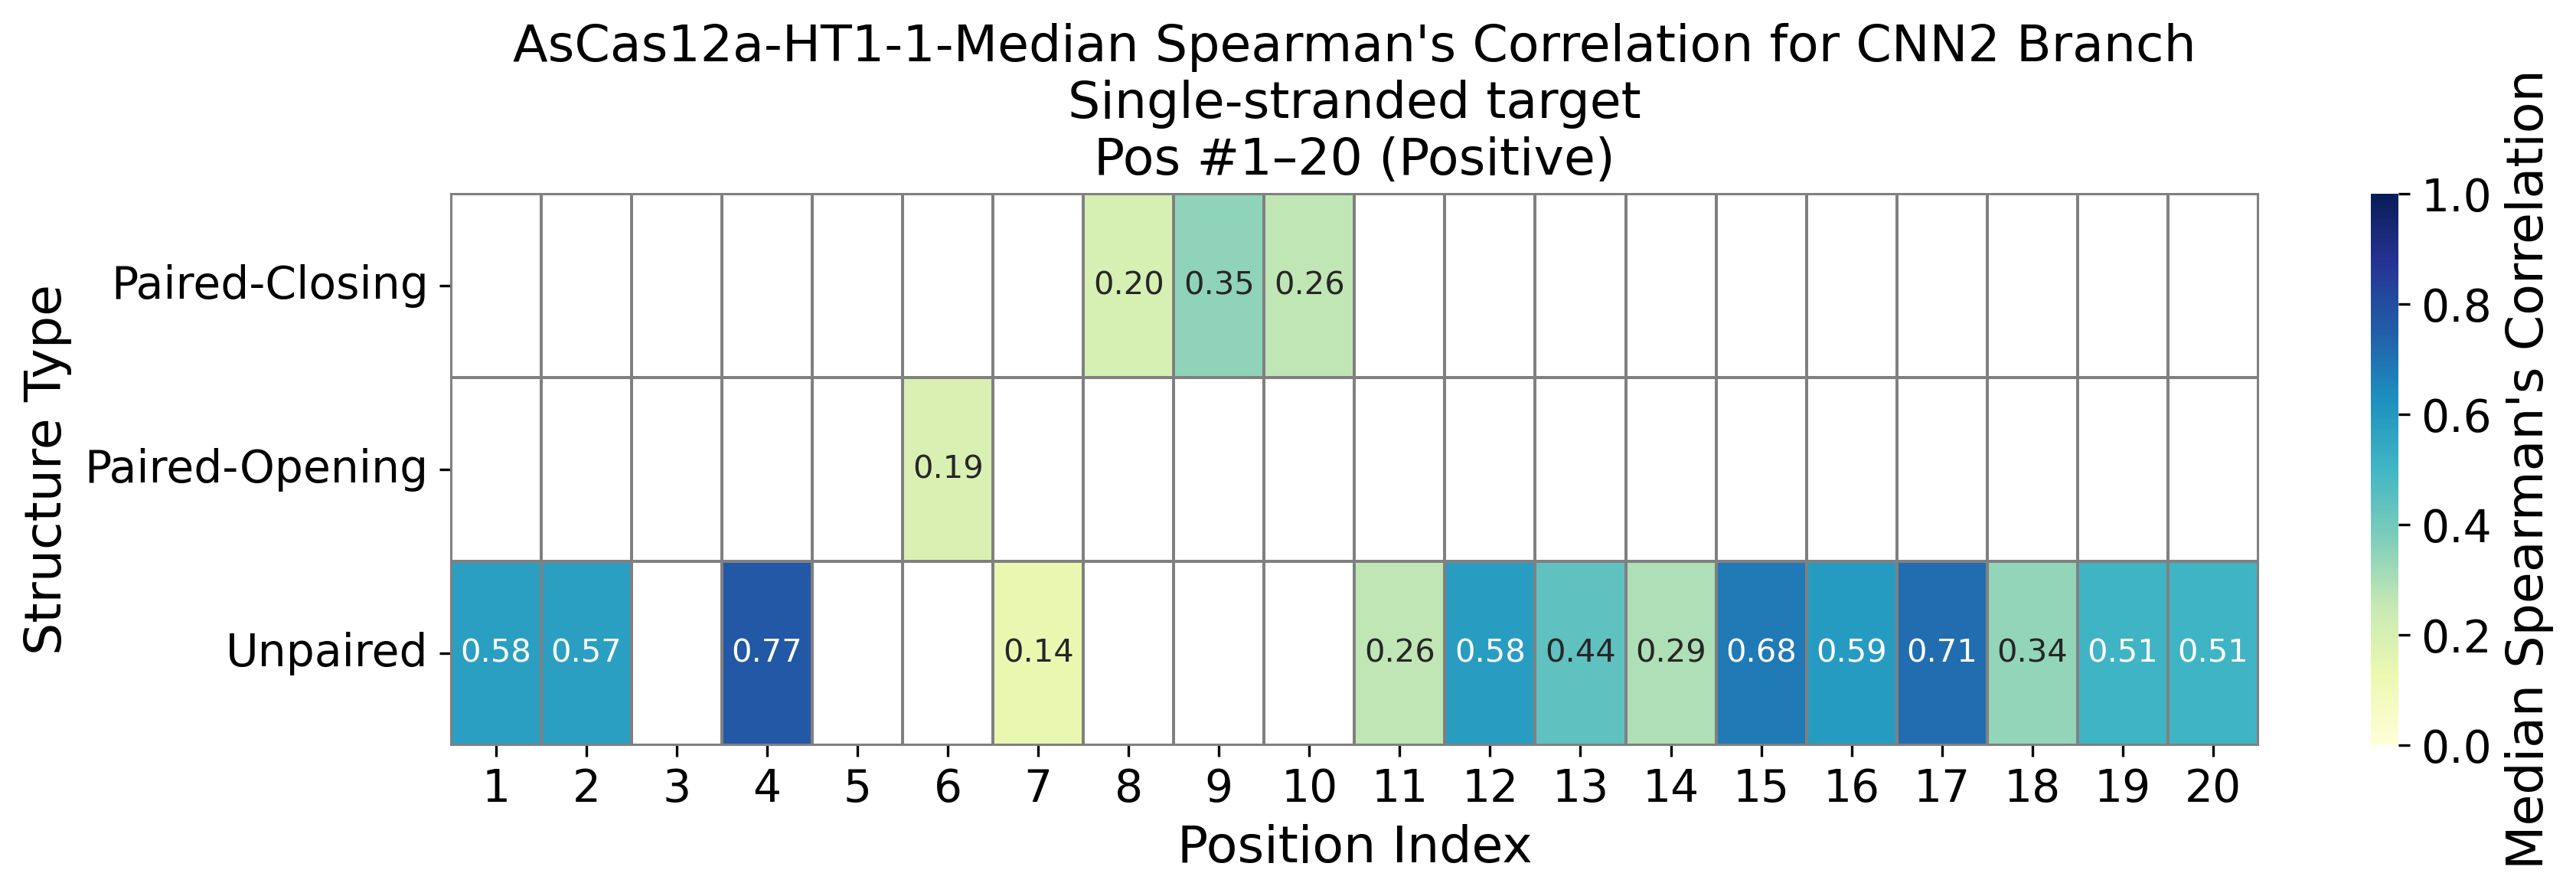

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load processed feature list ===
iqr_df = pd.read_csv("indiv_features_with_positive_IQR_HT11_cnn2_ssDNA_target_ah.csv")

# === Extract Pos and Base Type (here Base = sub-feature like Paired, Opening, etc.) ===
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(.+)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# === Handle duplicate (Base, Pos) entries by averaging ===
iqr_df_grouped = iqr_df.groupby(['Base', 'Pos'])["Median Spearman Correlation"].mean().reset_index()

# === Pivot to heatmap format ===
heatmap_data = iqr_df_grouped.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Force fixed row order with all three categories
row_order = ["Paired-Closing", "Paired-Opening", "Unpaired"]
heatmap_data = heatmap_data.reindex(row_order)

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(1, 41)  # 1 to 40 inclusive
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

# Create mask for missing values
mask = heatmap_data.isna()

# === Create two heatmap panels ===

# Heatmap for positions 1–20
fig1, ax1 = plt.subplots(figsize=(12, 4), dpi=300)
hm1 = sns.heatmap(
    heatmap_data.loc[:, 1:20],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 1:20].isna(),
    ax=ax1
)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax1.set_xlabel("Position Index", fontsize=16)
ax1.set_ylabel("Structure Type", fontsize=16)
ax1.set_title("AsCas12a-HT1-1-Median Spearman's Correlation for CNN2 Branch\n"
              "Single-stranded target\n"
              "Pos #1–20 (Positive)", fontsize=16)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar1 = hm1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=14)
cbar1.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

